In [4]:
import pandas as pd
import chess
import matplotlib.pyplot as plt

Number of boards by piece count:
2 pieces: 66
3 pieces: 4496
4 pieces: 7549
5 pieces: 9665
6 pieces: 11870
7 pieces: 13833
8 pieces: 15907
9 pieces: 18169
10 pieces: 20386
11 pieces: 22858
12 pieces: 25653
13 pieces: 27900
14 pieces: 30503
15 pieces: 32628
16 pieces: 34994
17 pieces: 36192
18 pieces: 38958
19 pieces: 39641
20 pieces: 43505
21 pieces: 43087
22 pieces: 48528
23 pieces: 45810
24 pieces: 54775
25 pieces: 45397
26 pieces: 61536
27 pieces: 41239
28 pieces: 68646
29 pieces: 31254
30 pieces: 66852
31 pieces: 14784
32 pieces: 43319

Cumulative counts (boards with ≤ n pieces):
≤ 2 pieces: 66
≤ 3 pieces: 4562
≤ 4 pieces: 12111
≤ 5 pieces: 21776
≤ 6 pieces: 33646
≤ 7 pieces: 47479
≤ 8 pieces: 63386
≤ 9 pieces: 81555
≤ 10 pieces: 101941
≤ 11 pieces: 124799
≤ 12 pieces: 150452
≤ 13 pieces: 178352
≤ 14 pieces: 208855
≤ 15 pieces: 241483
≤ 16 pieces: 276477
≤ 17 pieces: 312669
≤ 18 pieces: 351627
≤ 19 pieces: 391268
≤ 20 pieces: 434773
≤ 21 pieces: 477860
≤ 22 pieces: 526388
≤ 23 piec

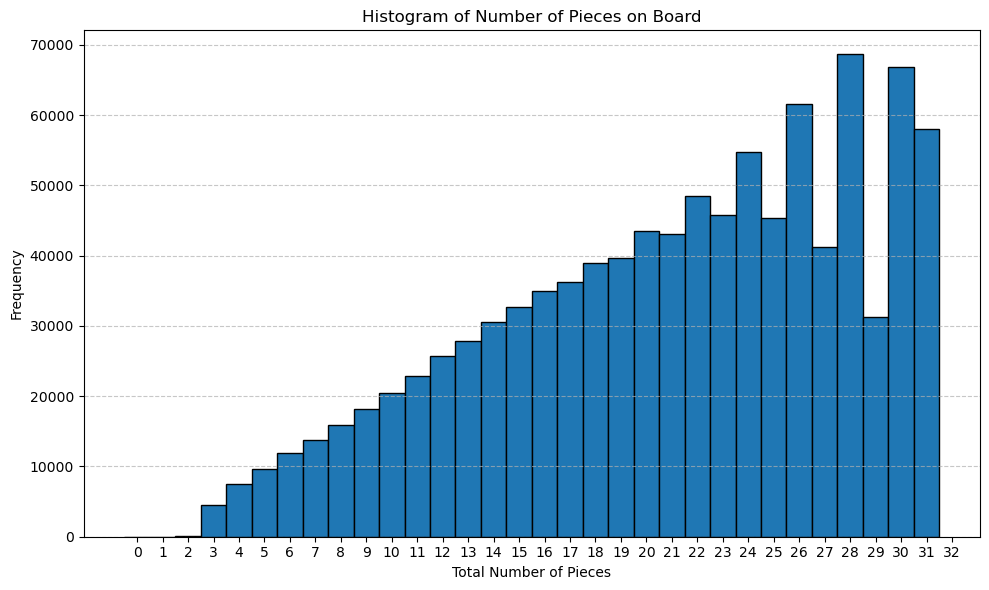

In [5]:
CSV_PATH = "data/deepmind_behavioral_cloning_train_1mm.csv"
df = pd.read_csv(CSV_PATH)

# --- Count pieces from FEN ---
def count_pieces(fen):
    board = chess.Board(fen)
    return len(board.piece_map())

df["num_pieces"] = df["FEN"].apply(count_pieces)

# --- Print exact counts ---
piece_counts = df["num_pieces"].value_counts().sort_index()
print("Number of boards by piece count:")
for pieces, count in piece_counts.items():
    print(f"{pieces} pieces: {count}")

print("\nCumulative counts (boards with ≤ n pieces):")
for n in range(2, 33):
    count_leq_n = (df["num_pieces"] <= n).sum()
    print(f"≤ {n} pieces: {count_leq_n}")

# --- Plot histogram ---
plt.figure(figsize=(10, 6))
plt.hist(df["num_pieces"], bins=range(0, 33), edgecolor='black', align='left')
plt.title("Histogram of Number of Pieces on Board")
plt.xlabel("Total Number of Pieces")
plt.ylabel("Frequency")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 33))
plt.tight_layout()
plt.show()